In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/train_ver2.csv.zip")

/tmp/ipykernel_2223/58743626.py:1: DtypeWarning: Columns (5,8,11,15) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/train_ver2.csv.zip")


In [3]:
data.shape

(13647309, 48)

In [4]:
data.head()

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35,2015-01-12,0.0,6,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
1,2015-01-28,1050611,N,ES,V,23,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
2,2015-01-28,1050612,N,ES,V,23,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
3,2015-01-28,1050613,N,ES,H,22,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
4,2015-01-28,1050614,N,ES,V,23,2012-08-10,0.0,35,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13647309 entries, 0 to 13647308
Data columns (total 48 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   fecha_dato             object 
 1   ncodpers               int64  
 2   ind_empleado           object 
 3   pais_residencia        object 
 4   sexo                   object 
 5   age                    object 
 6   fecha_alta             object 
 7   ind_nuevo              float64
 8   antiguedad             object 
 9   indrel                 float64
 10  ult_fec_cli_1t         object 
 11  indrel_1mes            object 
 12  tiprel_1mes            object 
 13  indresi                object 
 14  indext                 object 
 15  conyuemp               object 
 16  canal_entrada          object 
 17  indfall                object 
 18  tipodom                float64
 19  cod_prov               float64
 20  nomprov                object 
 21  ind_actividad_cliente  float64
 22  renta           

In [6]:
data["fecha_dato"].nunique(), data["fecha_dato"].min(), data["fecha_dato"].max()

(17, '2015-01-28', '2016-05-28')

In [7]:
data["ncodpers"].nunique()

956645

In [8]:
data.dtypes.value_counts()

int64      23
object     17
float64     8
Name: count, dtype: int64

In [9]:
data.isna().mean().sort_values(ascending=False).head()

conyuemp          0.999868
ult_fec_cli_1t    0.998183
renta             0.204756
segmento          0.013876
canal_entrada     0.013638
dtype: float64

In [10]:
data = data.drop(columns=["conyuemp", "ult_fec_cli_1t"])

In [11]:
target_cols = [c for c in data.columns if c.endswith("_ult1")]
data[target_cols] = data[target_cols].fillna(0).astype("int8")

for c in ['ind_nuevo', 'indrel', 'ind_actividad_cliente', 'tipodom', 'cod_prov']:
    data[c] = pd.to_numeric(data[c], errors='coerce').astype('float32')

data["ncodpers"] = data["ncodpers"].astype("int32")
data["age"] = pd.to_numeric(data["age"], errors="coerce").astype("float32")
data["antiguedad"] = pd.to_numeric(data["antiguedad"], errors="coerce")
data.loc[data["antiguedad"] < 0, "antiguedad"] = np.nan
data["antiguedad"] = data["antiguedad"].astype("float32")
data["renta"] = data["renta"].astype("float32")

In [12]:
print(data.memory_usage(deep=True).sum() / 1024**3, 'GB')

10.709890494123101 GB


In [13]:
data[target_cols].mean().sort_values(ascending=False)

ind_cco_fin_ult1     0.655484
ind_ctop_fin_ult1    0.129008
ind_recibo_ult1      0.127916
ind_ecue_fin_ult1    0.082744
ind_cno_fin_ult1     0.080867
ind_nom_pens_ult1    0.059359
ind_nomina_ult1      0.054660
ind_reca_fin_ult1    0.052536
ind_tjcr_fin_ult1    0.044389
ind_ctpp_fin_ult1    0.043306
ind_dela_fin_ult1    0.042967
ind_valo_fin_ult1    0.025608
ind_fond_fin_ult1    0.018486
ind_ctma_fin_ult1    0.009727
ind_ctju_fin_ult1    0.009474
ind_plan_fin_ult1    0.009171
ind_hip_fin_ult1     0.005887
ind_viv_fin_ult1     0.003848
ind_pres_fin_ult1    0.002627
ind_deco_fin_ult1    0.001779
ind_deme_fin_ult1    0.001661
ind_cder_fin_ult1    0.000394
ind_ahor_fin_ult1    0.000102
ind_aval_fin_ult1    0.000023
dtype: float64

In [14]:
data.groupby("fecha_dato")["ncodpers"].nunique()

fecha_dato
2015-01-28    625457
2015-02-28    627394
2015-03-28    629209
2015-04-28    630367
2015-05-28    631957
2015-06-28    632110
2015-07-28    829817
2015-08-28    843201
2015-09-28    865440
2015-10-28    892251
2015-11-28    906109
2015-12-28    912021
2016-01-28    916269
2016-02-28    920904
2016-03-28    925076
2016-04-28    928274
2016-05-28    931453
Name: ncodpers, dtype: int64

In [15]:
data["fecha_dato"] = pd.to_datetime(data["fecha_dato"])
data["fecha_alta"] = pd.to_datetime(data["fecha_alta"], errors="coerce")
cat_cols = data.select_dtypes("object").columns
data[cat_cols] = data[cat_cols].astype("category")

In [16]:
print(data.memory_usage(deep=True).sum() / 1024**3, 'GB')

1.1185157857835293 GB


In [17]:
cat_cols

Index(['ind_empleado', 'pais_residencia', 'sexo', 'indrel_1mes', 'tiprel_1mes',
       'indresi', 'indext', 'canal_entrada', 'indfall', 'nomprov', 'segmento'],
      dtype='object')

In [18]:
data["tipodom"].nunique()

1

In [19]:
data = data.drop(columns=["tipodom"])

In [20]:
data["month_id"] = data["fecha_dato"].dt.year * 12 + data["fecha_dato"].dt.month

prev = data[["ncodpers", "month_id"] + target_cols].copy()
prev["month_id"] += 1
prev = prev.rename(columns={c: c + "_prev" for c in target_cols})

df = data.merge(prev, on=["ncodpers", "month_id"], how="left")

has_prev = df[target_cols[0] + "_prev"].notna()
print("строк без предыдущего месяца:", (~has_prev).sum())

for c in target_cols:
    df[c + "_buy"] = ((df[c] == 1) & (df[c + "_prev"] == 0)).astype("int8")

buy_cols = [c + "_buy" for c in target_cols]
df.loc[~has_prev, buy_cols] = 0

строк без предыдущего месяца: 964888


In [21]:
df.groupby("fecha_dato")[buy_cols].sum().sum(axis=1) # покупок по месяцам

fecha_dato
2015-01-28        0
2015-02-28    31372
2015-03-28    31948
2015-04-28    30427
2015-05-28    26311
2015-06-28    41745
2015-07-28    33362
2015-08-28    29490
2015-09-28    35696
2015-10-28    39803
2015-11-28    35215
2015-12-28    42353
2016-01-28    30956
2016-02-28    49024
2016-03-28    35203
2016-04-28    32962
2016-05-28    35843
dtype: int64

In [22]:
df[buy_cols].sum().sort_values(ascending=False) # покупок по продуктам

ind_recibo_ult1_buy      153146
ind_nom_pens_ult1_buy     84709
ind_nomina_ult1_buy       73753
ind_tjcr_fin_ult1_buy     69118
ind_cco_fin_ult1_buy      69103
ind_cno_fin_ult1_buy      37098
ind_ecue_fin_ult1_buy     26361
ind_dela_fin_ult1_buy     12659
ind_reca_fin_ult1_buy      9234
ind_ctma_fin_ult1_buy      6856
ind_valo_fin_ult1_buy      4848
ind_ctop_fin_ult1_buy      3869
ind_fond_fin_ult1_buy      3693
ind_deco_fin_ult1_buy      3061
ind_ctpp_fin_ult1_buy      2418
ind_plan_fin_ult1_buy       618
ind_ctju_fin_ult1_buy       482
ind_deme_fin_ult1_buy       250
ind_pres_fin_ult1_buy       147
ind_cder_fin_ult1_buy       136
ind_hip_fin_ult1_buy         75
ind_viv_fin_ult1_buy         70
ind_aval_fin_ult1_buy         4
ind_ahor_fin_ult1_buy         2
dtype: int64

In [23]:
(df[buy_cols].sum(axis=1) > 0).mean() # доля строк с хотя бы одной покупкой

np.float64(0.032717878667508735)

Text(0, 0.5, 'Число покупок')

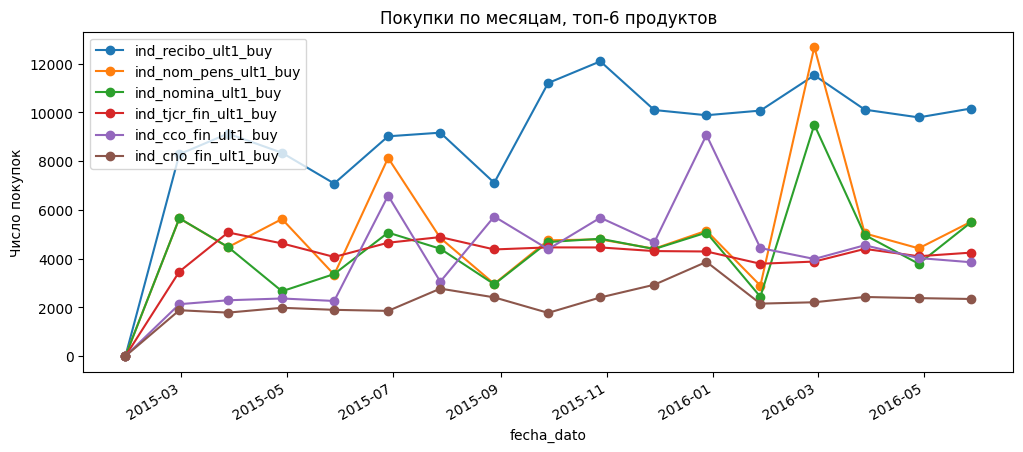

In [24]:
# 1. Сезонность покупок по топ-продуктам
monthly = df.groupby("fecha_dato")[buy_cols].sum()
top = monthly.sum().nlargest(6).index
monthly[top].plot(figsize=(12, 5), marker="o")
plt.title("Покупки по месяцам, топ-6 продуктов")
plt.ylabel("Число покупок")

<Axes: title={'center': 'log(renta)'}, ylabel='Frequency'>

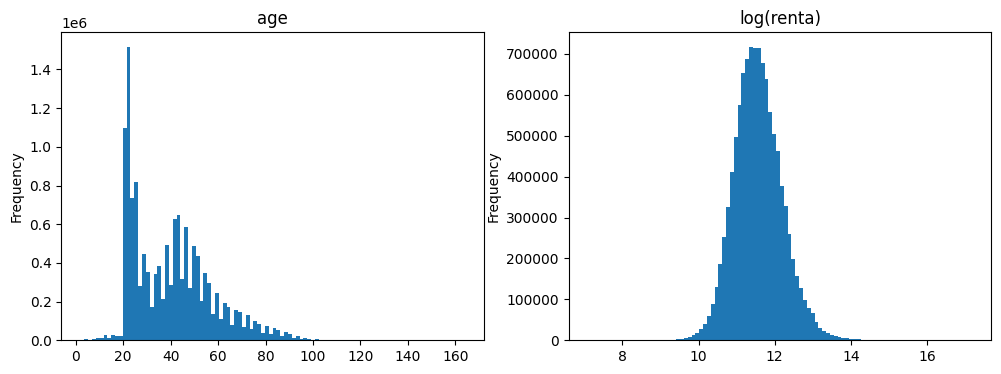

In [25]:
# 2. Возраст и доход: выбросы
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["age"].plot.hist(bins=100, ax=ax[0], title="age")
np.log1p(df["renta"]).plot.hist(bins=100, ax=ax[1], title="log(renta)")

In [26]:
# 3. Частота покупки в разрезе сегментов
for col in ["segmento", "ind_actividad_cliente", "tiprel_1mes"]:
    rate = df.groupby(col, observed=True)[buy_cols].sum().sum(axis=1) / df.groupby(col, observed=True).size()
    print(col, "\n", rate.sort_values(ascending=False), "\n")

segmento 
 segmento
01 - TOP              0.110565
02 - PARTICULARES     0.048851
03 - UNIVERSITARIO    0.022284
dtype: float64 

ind_actividad_cliente 
 ind_actividad_cliente
1.0    0.086563
0.0    0.002904
dtype: float64 

tiprel_1mes 
 tiprel_1mes
A    0.085384
P    0.028780
I    0.004484
N    0.000000
R    0.000000
dtype: float64 



<Axes: >

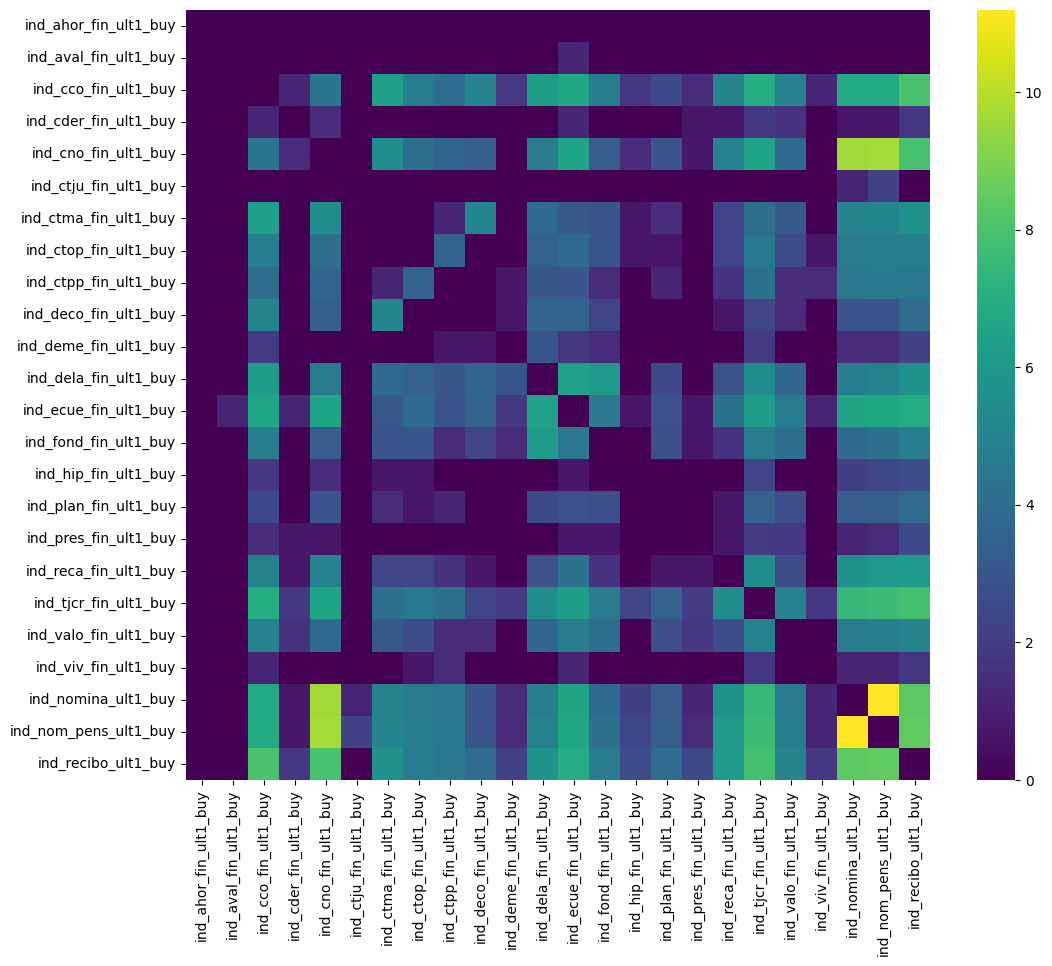

In [27]:
# 4. Матрица совместных покупок
co = df[buy_cols].astype("int32").T.dot(df[buy_cols].astype("int32"))
np.fill_diagonal(co.values, 0)
plt.figure(figsize=(12, 10))
sns.heatmap(np.log1p(co), cmap="viridis")

<Axes: xlabel='antiguedad'>

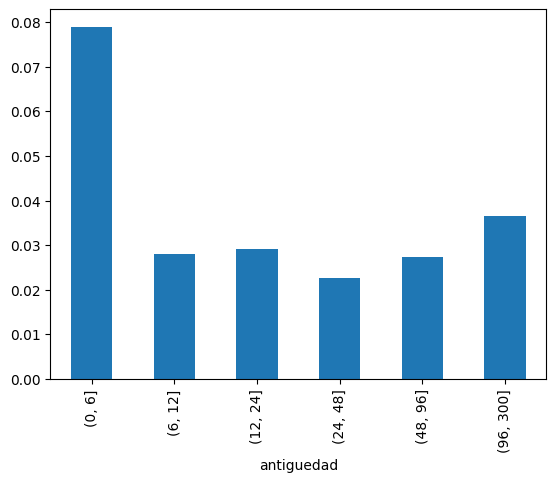

In [28]:
# 5. Стаж клиента и покупки
bins = pd.cut(df["antiguedad"], [0, 6, 12, 24, 48, 96, 300])
df.groupby(bins, observed=True).apply(lambda g: (g[buy_cols].sum(axis=1) > 0).mean()).plot(kind="bar")

In [30]:
s = df["indrel_1mes"].astype(str).str.strip()
s = s.replace({"1.0": "1", "2.0": "2", "3.0": "3", "4.0": "4", "nan": None})
df["indrel_1mes"] = s.astype("category")

print(df["indrel_1mes"].value_counts(dropna=False))

indrel_1mes
1      13490681
NaN      149781
3          4350
2          1317
P           874
4           306
Name: count, dtype: int64


In [31]:
for c in df.select_dtypes("category").columns:
    types = {type(x).__name__ for x in df[c].cat.categories}
    if len(types) > 1:
        print(c, types)

In [32]:
from pathlib import Path
import json

DATA = Path("../data/interim")
DATA.mkdir(parents=True, exist_ok=True)

df.drop(columns=[c for c in df.columns if c.endswith("_prev")]).to_parquet(
    DATA / "monthly_with_buys.parquet", compression="zstd", index=False
)

meta = {
    "target_cols": target_cols,
    "rare": ["ind_ahor_fin_ult1", "ind_aval_fin_ult1"],
    "val_month": int(df["month_id"].max()),
    "random_state": 42,
}
(DATA / "meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2))

727

## Выводы по EDA

**Данные.** 13.6 млн записей, 956 645 клиентов, 17 месяцев с 2015-01-28 по 2016-05-28,
пропусков в календаре нет. Между июнем и июлем 2015 база скачком выросла с 632 до
830 тысяч: это артефакт усечения исходной выгрузки, а не приток клиентов. Следствие:
первая строка таких клиентов не имеет корректного предыдущего месяца и исключается
из расчёта таргета (964 888 строк, 7.1%).

**Качество.** Удалены `conyuemp` (99.99% пропусков), `ult_fec_cli_1t` (99.8%) и
`tipodom` (константа). Числовые поля приходили строками: `age`, `antiguedad`,
`indrel_1mes`; в `antiguedad` присутствует заглушка -999999, заменена на NaN.
`age` распределён бимодально (пик около 20 лет у сегмента `UNIVERSITARIO` и широкий
на 40-50) с невозможными значениями до 164 лет. `renta` логнормальна, 20% пропусков.
Пропуски намеренно не заполняются на этапе анализа: статистики импутации должны
считаться внутри пайплайна на обучающей части во избежание утечки. Приведение типов
и перевод строк в category сократили объём с 10.7 до 1.1 ГБ.

**Ключевое наблюдение.** Порядок продуктов по владению и по покупкам расходится.
`ind_cco_fin_ult1` первый по владению (65.5%), но лишь пятый по числу приобретений,
поскольку у большинства уже есть. `ind_recibo_ult1` при владении 12.8% даёт 153 146
покупок, больше любого другого продукта. Отсюда постановка задачи: целевое событие
это переход владения из 0 в 1 между соседними месяцами, а не факт владения. Модель,
обученная на владении, выродится в рекомендацию текущего счёта всем подряд.

**Целевое событие.** 561 704 покупки, встречаются в 3.27% строк, в среднем 1.26
продукта на клиента в момент покупки. Топ-3 продукта дают
55% событий; `ind_ahor_fin_ult1` (2 покупки) и `ind_aval_fin_ult1` (4) исключаются
из обучения. `ind_nomina_ult1` и `ind_nom_pens_ult1` покупаются синхронно, их пики
на графике сезонности совпадают.

**Факторы склонности к покупке.**

| Признак | Частота покупки |
|---|---|
| `ind_actividad_cliente` | 8.66% против 0.29%, различие в 30 раз |
| `segmento` | VIP 11.06%, обычные 4.89%, студенты 2.23% |
| `tiprel_1mes` | A 8.54%, P 2.88%, I 0.45%, у N и R покупок нет |

Активность клиента это сильнейший одиночный предиктор, но брать её нужно в лаговой
форме: смена статуса может происходить одновременно с покупкой. Связь стажа с
покупкой немонотонна и U-образна: 7.9% у новичков первых шести месяцев, спад до 2.3%
на горизонте 24-48 месяцев, рост до 3.7% у клиентов со стажем свыше 96 месяцев.
Линейная модель такую форму не уловит.

**Сезонность.** Помесячная динамика нестационарна: синхронные всплески `nomina` и
`nom_pens` в июле 2015 и марте 2016, провал в феврале 2016, отдельный пик `ind_cco`
в январе 2016. Значит, месяц нужен как признак, а валидация строго временная:
обучение на прошлом, проверка на 2016-05.